# Word Graph Paper

## Import Library & Setup NLTK

In [ ]:
!pip -q install pymupdf networkx pandas matplotlib seaborn nltk

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pymupdf
import nltk
from nltk.corpus import stopwords
from collections import Counter
import numpy as np

%matplotlib inline

# --- DOWNLOAD RESOURCES NLTK ---
def load_nltk_resources():
    resources = ['punkt', 'stopwords']
    for res in resources:
        try:
            nltk.data.find(f'tokenizers/{res}' if res == 'punkt' else f'corpora/{res}')
        except LookupError:
            print(f"Downloading {res}...")
            nltk.download(res)

load_nltk_resources()
print("Library berhasil di-load.")

Library berhasil di-load.


## Fungsi Preprocessing

In [ ]:
def processor_text(text_input):
    if not isinstance(text_input, str): return []

    # Cleaning steps
    text_input = text_input.replace('◼', '').lower()
    text_input = re.sub(r'\b(\w+)-\1\b', r'\1', text_input) # Reduplikasi
    text_input = text_input.translate(str.maketrans('', '', string.punctuation)) # Tanda baca
    text_input = re.sub(r'\d+', '', text_input) # Angka
    text_input = re.sub(r'\b[a-zA-Z]\b', ' ', text_input) # Huruf tunggal
    text_input = re.sub(r'\s+', ' ', text_input).strip() # Spasi ganda

    # Stopwords
    try:
        stop_ids = set(stopwords.words('indonesian'))
    except:
        nltk.download('stopwords')
        stop_ids = set(stopwords.words('indonesian'))

    # Tokenizing & Filtering
    tokens_result = [t for t in text_input.split() if t not in stop_ids and len(t) > 2]

    return tokens_result

## Upload & Baca File

In [ ]:
FILE_PATH = "56-111-1-SM.pdf"
TOP_N_NODES = 25

# --- PROSES MEMBACA FILE ---
try:
    if FILE_PATH.endswith(".pdf"):
        doc = pymupdf.open(FILE_PATH)
        raw_text = " ".join([page.get_text() for page in doc])
        print(f"Berhasil membaca PDF. Total halaman: {len(doc)}")
    else:
        with open(FILE_PATH, 'r', encoding='utf-8') as f:
            raw_text = f.read()
        print("Berhasil membaca file TXT.")

    # Proses Cleaning
    final_tokens = processor_text(raw_text)
    print(f"Jumlah kata bersih: {len(final_tokens)}")
    print(f"Preview: {final_tokens[:20]} ...")

except Exception as e:
    print(f"Error membaca file: {e}")
    print("Pastikan nama file di variabel FILE_PATH sudah benar dan file sudah diupload.")
    final_tokens = []

Berhasil membaca PDF. Total halaman: 8
Jumlah kata bersih: 1583
Preview: ['kesatria', 'jurnal', 'penerapan', 'sistem', 'informasi', 'komputer', 'manajemen', 'vol', 'januari', 'issn', 'copyright', 'kesatria', 'jurnal', 'penerapan', 'sistem', 'informasi', 'komputer', 'manajemen', 'implementasi', 'data'] ...


## Frekuensi Kata

--- DISTRIBUSI KATA TERPOPULER ---


/tmp/ipython-input-90627656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, y='Term', x='Count', palette='mako')


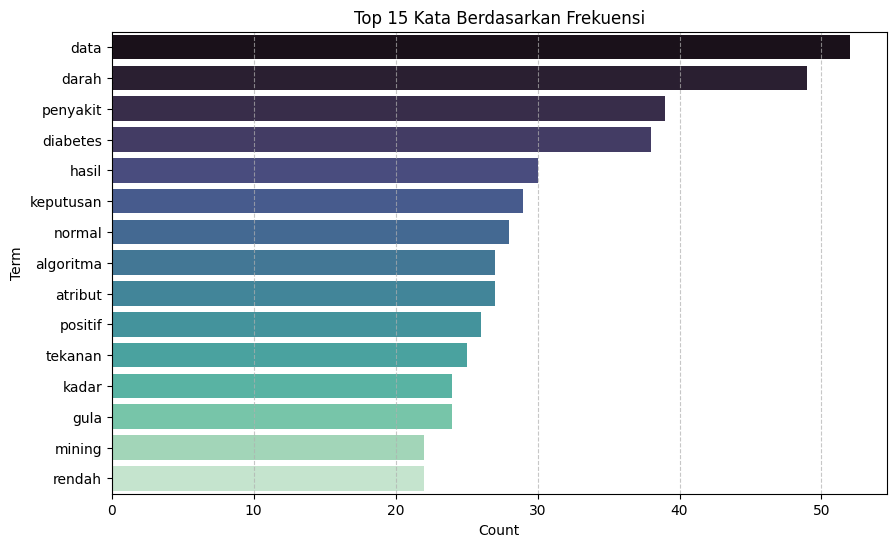

In [ ]:
if final_tokens:
    print("--- DISTRIBUSI KATA TERPOPULER ---")
    count_data = Counter(final_tokens).most_common(15)
    df_counts = pd.DataFrame(count_data, columns=['Term', 'Count'])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_counts, y='Term', x='Count', palette='mako')
    plt.title("Top 15 Kata Berdasarkan Frekuensi")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## Network Graph

--- PETA JARINGAN KATA (Top 25 Node) ---


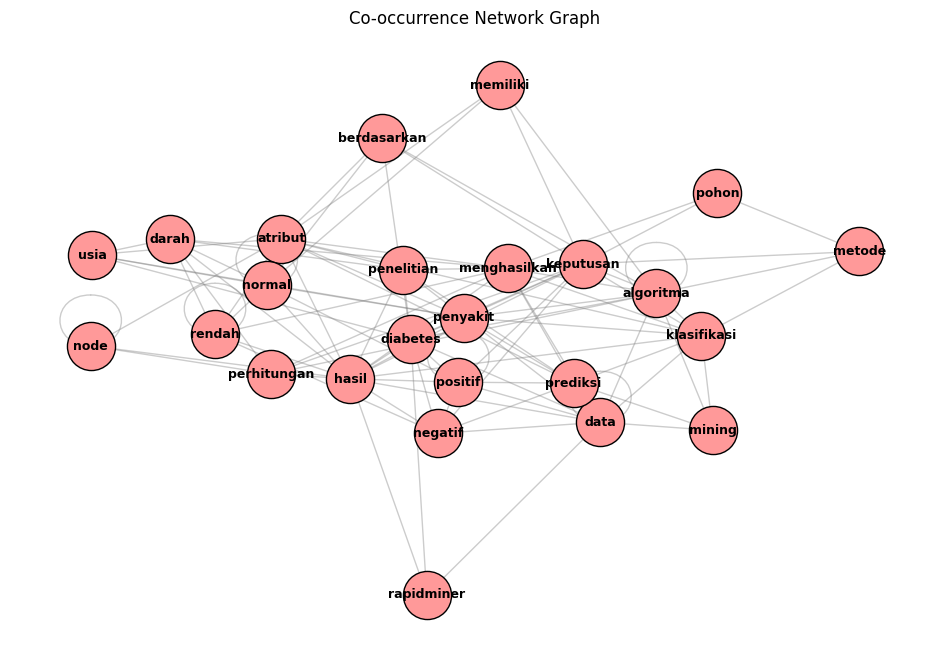


📊 DETAIL PERHITUNGAN GRAPH:

1. Top 25 Kata dengan Koneksi Terbanyak (Centrality):


,Kata (Node),Jumlah Koneksi (Degree)
0,data,53
1,diabetes,45
2,algoritma,41
3,penyakit,38
4,hasil,33
5,keputusan,32
6,atribut,31
7,usia,21
8,menghasilkan,20
9,klasifikasi,20



2. Top 15 Pasangan Kata yang Paling Sering Muncul Bersama:


,Kata A,Kata B,Bobot (Frekuensi Bersama)
0,penyakit,diabetes,28
1,tekanan,darah,27
2,kadar,gula,24
3,data,mining,23
4,darah,gula,23
5,berat,badan,19
6,old,positif,17
7,normal,rendah,14
8,pohon,keputusan,13
9,hasil,perhitungan,12


In [ ]:
if final_tokens:
    print(f"--- PETA JARINGAN KATA (Top {TOP_N_NODES} Node) ---")

    # 1. Build Graph
    G = nx.Graph()
    for i in range(len(final_tokens)-1):
        edge = sorted([final_tokens[i], final_tokens[i+1]])
        if G.has_edge(edge[0], edge[1]):
            G[edge[0]][edge[1]]['weight'] += 1
        else:
            G.add_edge(edge[0], edge[1], weight=1)

    # 2. Hitung Degree Centrality (Untuk filtering)
    d = dict(G.degree)
    # Mengurutkan node dari degree tertinggi ke terendah
    sorted_nodes = sorted(d, key=d.get, reverse=True)[:TOP_N_NODES]

    # 3. Visualisasi Subgraph
    subG = G.subgraph(sorted_nodes)
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(subG, k=0.5, seed=42)

    nx.draw_networkx_nodes(subG, pos, node_size=1200, node_color='#ff9999', edgecolors='black')
    nx.draw_networkx_edges(subG, pos, width=1, alpha=0.4, edge_color='grey')
    nx.draw_networkx_labels(subG, pos, font_size=9, font_weight="bold")

    plt.axis('off')
    plt.title("Co-occurrence Network Graph")
    plt.show()

    # Simpan Graph penuh untuk PageRank nanti
    full_G = G

    # --- TAMBAHAN: MENAMPILKAN DATA HASIL PERHITUNGAN ---
    print("\n📊 DETAIL PERHITUNGAN GRAPH:")

    # A. Menampilkan Tabel Degree (Jumlah Koneksi per Kata)
    # Mengubah data degree node terpilih menjadi DataFrame
    data_degree = [{'Kata (Node)': node, 'Jumlah Koneksi (Degree)': d[node]} for node in sorted_nodes]
    df_degree = pd.DataFrame(data_degree)

    print(f"\n1. Top {TOP_N_NODES} Kata dengan Koneksi Terbanyak (Centrality):")
    try:
        display(df_degree)
    except NameError:
        print(df_degree)

    # B. Menampilkan Tabel Edge Weight (Kekuatan Hubungan Antar Kata)
    # Mengambil data bobot edge dari graph penuh
    edge_data = []
    for u, v, attributes in G.edges(data=True):
        edge_data.append({
            'Kata A': u,
            'Kata B': v,
            'Bobot (Frekuensi Bersama)': attributes['weight']
        })

    df_edges = pd.DataFrame(edge_data)
    # Urutkan berdasarkan bobot tertinggi
    df_edges_sorted = df_edges.sort_values(by='Bobot (Frekuensi Bersama)', ascending=False).reset_index(drop=True)

    print("\n2. Top 15 Pasangan Kata yang Paling Sering Muncul Bersama:")
    try:
        display(df_edges_sorted.head(15))
    except NameError:
        print(df_edges_sorted.head(15))

else:
    print("Tidak ada token untuk diproses.")

## Heatmap Hubungan

--- HEATMAP HUBUNGAN ANTAR KATA ---


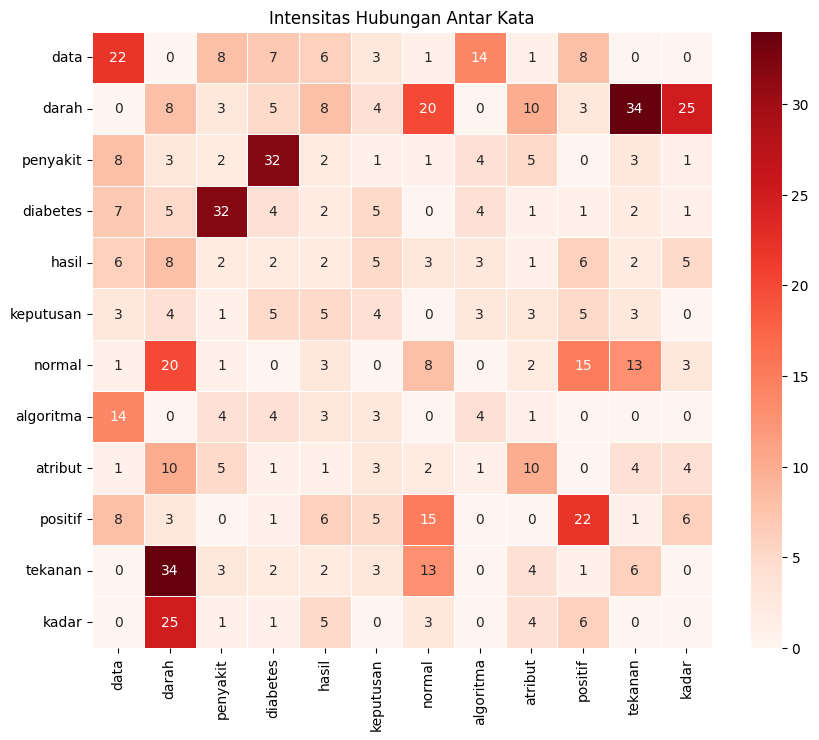

In [ ]:
if final_tokens:
    print("--- HEATMAP HUBUNGAN ANTAR KATA ---")

    # Ambil Top 12 kata untuk heatmap
    target_words = [x[0] for x in count_data[:12]]
    mat_df = pd.DataFrame(0, index=target_words, columns=target_words)

    window = 3
    for i, w in enumerate(final_tokens):
        if w in target_words:
            start = max(0, i - window)
            end = min(len(final_tokens), i + window + 1)
            for j in range(start, end):
                if i != j and final_tokens[j] in target_words:
                    mat_df.loc[w, final_tokens[j]] += 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(mat_df, annot=True, fmt="d", cmap="Reds", linewidths=.5)
    plt.title("Intensitas Hubungan Antar Kata")
    plt.show()

## PageRank (Ranking Keyword)

In [ ]:
if final_tokens:
    print("--- HASIL ANALISIS SENTRALITAS (PAGERANK) ---")

    # Hitung PageRank
    try:
        # Menambahkan parameter tol jika graph sangat besar/sulit konvergen
        pr_scores = nx.pagerank(full_G, weight='weight')
    except Exception as e:
        print(f"Error calculating PageRank: {e}")
        pr_scores = {}

    sorted_rank = sorted(pr_scores.items(), key=lambda x: x[1], reverse=True)
    df_rank = pd.DataFrame(sorted_rank, columns=['Kata Kunci', 'Skor'])

    # Tampilkan Top 3
    print("\n🏆 TOP 3 KEYWORDS:")
    for i in range(min(3, len(df_rank))):
        print(f"{i+1}. {df_rank.iloc[i]['Kata Kunci']} (Skor: {df_rank.iloc[i]['Skor']:.4f})")

    # Tampilkan Tabel
    print("\n📋 TABEL DETAIL (Top 10):")
    display(df_rank.head(10))

--- HASIL ANALISIS SENTRALITAS (PAGERANK) ---

🏆 TOP 3 KEYWORDS:
1. data (Skor: 0.0267)
2. diabetes (Skor: 0.0222)
3. penyakit (Skor: 0.0220)

📋 TABEL DETAIL (Top 10):


,Kata Kunci,Skor
0,data,0.026667
1,diabetes,0.022190
2,penyakit,0.021984
3,algoritma,0.014730
4,keputusan,0.014420
5,darah,0.012877
6,hasil,0.011761
7,mining,0.011497
8,atribut,0.011259
9,vol,0.009102
